In [2]:
# 데이터 불러오기

# pandas는 표 형태 데이터 처리, numpy는 수치 계산에 사용합니다.
import pandas as pd
import numpy as np

# 사용할 CSV 파일의 경로를 지정합니다.
path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'
# CSV 파일을 읽어 pandas DataFrame으로 만듭니다.
df = pd.read_csv(path)

In [3]:
# 뽑아서 확인

# 데이터가 제대로 불러와졌는지 앞부분을 확인합니다.
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 전처리 과정임 필요없는 데이터 삭제

# 학습에 직접 사용하기 어렵거나 식별자 성격이 강한 컬럼을 제거합니다.
df = df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1)

# 결측치 확인
# 각 컬럼에 결측치가 몇 개 있는지 확인합니다.
df.isnull().sum()

# 결측치
# Age 결측치는 전체 평균값으로 채웁니다.
df['Age'] = df['Age'].fillna(df['Age'].mean()) #평균으로
# Embarked 결측치는 가장 자주 등장한 값으로 채웁니다.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # 최빈값

# 범주형 데이터는 인코딩
# 문자열 범주형 변수는 원-핫 인코딩으로 숫자 컬럼으로 변환합니다.
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


머신러닝에서 y train은 문자열이어도 상관 없지만 "연속적인" 숫자로 변환해서 꼭 사용.
feature는 머신러닝, 딥러닝 둘다 사용 불가능. 숫자로 된 데이터는 상관 없이 사용 가능



Label Encoder >


import pandas as pd

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()



Name 컬럼 인코딩 >

df['Name_encoded'] = le.fit_transform(df['Name'])


In [5]:
# 생존 여부 기준 모델, 전처리 끝났으니까 데이터 넣기

# 예측해야 할 정답(label 또는 target) 컬럼을 y에 저장합니다.
y = df['Survived']

# 모델 입력에 사용할 특징(feature) 데이터를 X에 저장합니다.
X = df.drop('Survived', axis=1)

# label 개수 확인
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [6]:
# 데이터를 학습용과 테스트용으로 나누기 위한 함수를 불러옵니다.
from sklearn.model_selection import train_test_split

# 전체 데이터 중 75%는 학습, 25%는 테스트에 사용합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [7]:
# 로지스틱 회귀는 분류 문제에서 기준 모델로 자주 사용됩니다.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 로지스틱 회귀 모델 객체를 생성합니다.
model = LogisticRegression(max_iter=5000)

# 학습 데이터로 모델을 훈련합니다.
model.fit(X_train, y_train)

# 테스트 데이터에 대한 예측값을 생성합니다.
pred = model.predict(X_test)

print("Logistic Regression 정확도")
# 정확도는 전체 테스트 데이터 중 맞힌 비율을 의미합니다.
print(accuracy_score(y_test, pred))
print("Confusion Matrix")
# 혼동 행렬은 실제 클래스와 예측 클래스의 대응 관계를 보여줍니다.
print(confusion_matrix(y_test, pred))

Logistic Regression 정확도
0.7937219730941704
Confusion Matrix
[[116  23]
 [ 23  61]]


In [8]:

# 결정 트리는 조건을 나누며 분류 규칙을 학습하는 모델입니다.
from sklearn.tree import DecisionTreeClassifier

# 결정 트리 분류 모델을 생성합니다. random_state는 결과 재현을 위한 값입니다.
clf_dt = DecisionTreeClassifier(random_state=0)
# 학습 데이터로 모델을 훈련합니다.
clf_dt.fit(X_train, y_train)

# 테스트 데이터에 대한 예측값을 생성합니다.
pred_dt = clf_dt.predict(X_test)

print ("\n--- Decision Tree Classifier ---")
# 정확도는 전체 테스트 데이터 중 맞힌 비율을 의미합니다.
print (accuracy_score(y_test, pred_dt))
# 혼동 행렬은 실제 클래스와 예측 클래스의 대응 관계를 보여줍니다.
print (confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.757847533632287
[[113  26]
 [ 28  56]]


In [9]:
# 랜덤 포레스트는 여러 결정 트리를 묶어 분류 성능을 높이는 앙상블 모델입니다.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# pandas는 표 형태 데이터 처리, numpy는 수치 계산에 사용합니다.
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print ("\n--- Radom Forest ---")
# 랜덤 포레스트 분류 모델을 생성합니다.
rf_clf = RandomForestClassifier(random_state=0)
# 학습 데이터로 모델을 훈련합니다.
rf_clf.fit(X_train, y_train)
# 테스트 데이터에 대한 예측값을 생성합니다.
pred = rf_clf.predict(X_test)
# 정확도는 전체 테스트 데이터 중 맞힌 비율을 의미합니다.
print(accuracy_score(y_test,pred))
# 혼동 행렬은 실제 클래스와 예측 클래스의 대응 관계를 보여줍니다.
print (confusion_matrix(y_test, pred))


--- Radom Forest ---
0.8340807174887892
[[123  16]
 [ 21  63]]


In [10]:
# KNN은 가까운 이웃 데이터의 라벨을 보고 분류하는 모델입니다.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 가장 가까운 이웃 3개를 기준으로 분류하도록 설정합니다.
knn = KNeighborsClassifier(n_neighbors=3)

# 학습 데이터로 모델을 훈련합니다.
knn.fit(X_train, y_train)

# 테스트 데이터에 대한 예측값을 생성합니다.
pred_knn = knn.predict(X_test)

print("\n--- KNN Classifier ---")
# 정확도는 전체 테스트 데이터 중 맞힌 비율을 의미합니다.
print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Confusion Matrix:")
# 혼동 행렬은 실제 클래스와 예측 클래스의 대응 관계를 보여줍니다.
print(confusion_matrix(y_test, pred_knn))


--- KNN Classifier ---
Accuracy: 0.7040358744394619
Confusion Matrix:
[[113  26]
 [ 40  44]]


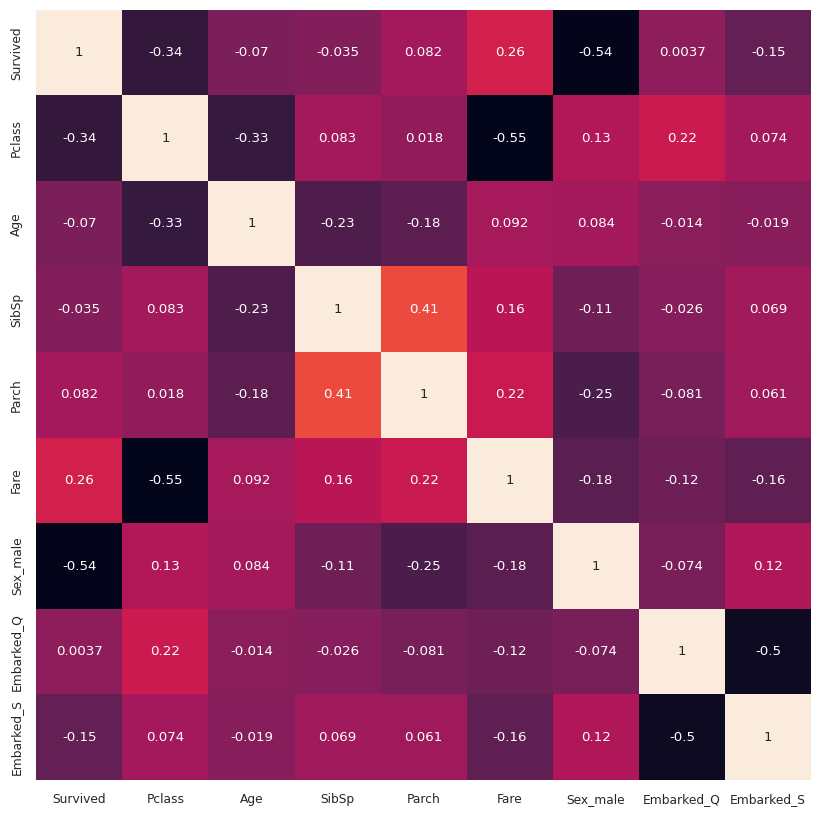

In [13]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

# corr()는 숫자형 컬럼들 사이의 상관계수를 계산합니다.
df_corr=df.corr()

#히트맵
# 그래프가 그려질 전체 화면 크기를 설정합니다.
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
# 상관관계를 색으로 표현해 어떤 변수가 관련이 큰지 쉽게 확인합니다.
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()